### Extracting Machine Learning-Ready hERG Data from the ChEMBL Database 

In this notebook, we will do the following:
- Download and uncompress the ChEMBL database
- Run an SQL query to extract hERG IC50 data from patch-clamp assays
- Aggregate the data to take the mean of multiple replaicates
- Build a quick machine learning model

**Note that downloading and extracting the ChEMBL database takes about 10 minutes**

In [23]:
!uv pip install pandas seaborn useful_rdkit_utils scikit-learn lightgbm scipy 

Using Python 3.12.13 environment at: /opt/homebrew/Caskroom/miniforge/base/envs/rdkit_2026_04
Audited 6 packages in 73ms


In [24]:
import sqlite3
import pandas as pd
import seaborn as sns
import useful_rdkit_utils as uru
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
from pathlib import Path

### 1. Grab the Data
If you're running this notebook locally set `chembl_sqlite_path` to point to the database file. 
- Set the path to the database file
- Check to see if the ChEMBL database is installed
- If not, download it and uncompress the archive.  In total, this should take about 10 minutes

In [9]:
chembl_sqlite_path = "chembl_36/chembl_36_sqlite/chembl_36.db"
if not chembl_sqlite_path.exists():
    !wget https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/chembl_36_sqlite.tar.gz
    !!tar -xzvf chembl_36_sqlite.tar.gz

Connect to the database

In [10]:
con = sqlite3.connect(chembl_sqlite_path)
cursor = con.cursor()

An SQL query to grab hERG patch clamp IC50 data from ChEMBL.  Note that this only grabs data with pchembl values.  It will exclude values with operators like ">" or "<". 

In [11]:
chembl_patchclamp_query = """
SELECT DISTINCT
    a.activity_id,
    md.chembl_id                AS molecule_chembl_id,
    cs_struct.canonical_smiles,
    a.standard_type,
    a.standard_value,
    a.standard_relation,
    a.standard_units,
    a.pchembl_value,
    ass.assay_id,
    ass.description              AS assay_description,
    td.tid                      AS target_id,
    td.chembl_id                AS target_chembl_id,
    seq_cs.accession            AS uniprot_ac
FROM activities a
         JOIN assays ass             ON a.assay_id = ass.assay_id
         JOIN target_dictionary td   ON ass.tid = td.tid
         JOIN target_components tc   ON td.tid = tc.tid
         JOIN component_sequences seq_cs ON tc.component_id = seq_cs.component_id
         JOIN molecule_dictionary md ON a.molregno = md.molregno
         JOIN compound_structures cs_struct ON md.molregno = cs_struct.molregno
WHERE seq_cs.accession = 'Q12809'
  AND a.pchembl_value IS NOT NULL
  AND a.standard_type = 'IC50'
  AND (
    LOWER(COALESCE(ass.description, '')) LIKE '%patch%'
        OR LOWER(COALESCE(ass.assay_type, '')) LIKE '%patch%'
    )
ORDER BY a.pchembl_value DESC;"""

Run the query

In [12]:
%%time 
res = cursor.execute(chembl_patchclamp_query)

CPU times: user 1.85 s, sys: 973 ms, total: 2.82 s
Wall time: 7.56 s


Put the query results into a Pandas dataframe

In [13]:
data = res.fetchall()
columns = [column[0] for column in res.description]
df = pd.DataFrame(data, columns=columns)
df.head()

,activity_id,molecule_chembl_id,canonical_smiles,standard_type,standard_value,standard_relation,standard_units,pchembl_value,assay_id,assay_description,target_id,target_chembl_id,uniprot_ac
0,25442946,CHEMBL4595328,O=C(N[C@H]1CC[C@@]2(O)[C@H]3Cc4ccc(O)c5c4[C@@]...,IC50,0.021,=,nM,10.68,2307090,Inhibition of human ERG expressed in CHO-K1 ce...,165,CHEMBL240,Q12809
1,25442947,CHEMBL327980,Cc1cccc(CCN2CCC(C(=O)c3ccc(NS(C)(=O)=O)cc3)CC2)n1,IC50,0.029,=,nM,10.54,2307090,Inhibition of human ERG expressed in CHO-K1 ce...,165,CHEMBL240,Q12809
2,25442945,CHEMBL5432371,Cc1cc2cccc(C(=O)N[C@H]3CC[C@@]4(O)[C@H]5Cc6ccc...,IC50,0.140,=,nM,9.85,2307090,Inhibition of human ERG expressed in CHO-K1 ce...,165,CHEMBL240,Q12809
3,27918971,CHEMBL5944633,C[C@@H]1Cc2c(ccc3[nH]nc(F)c23)[C@@H](c2cnc(NC3...,IC50,0.690,=,nM,9.16,2592326,Binding Assay : hERG (human ether go go-relate...,165,CHEMBL240,Q12809
4,27918938,CHEMBL6009034,C[C@@H]1Cc2c(ccc3[nH]ncc23)[C@@H](c2ccc(NC3CN(...,IC50,0.810,=,nM,9.09,2592326,Binding Assay : hERG (human ether go go-relate...,165,CHEMBL240,Q12809


See how many records we returned

In [14]:
len(df)

3879

Aggregate the data by ChEMBL ID

In [15]:
new_df = df.groupby('molecule_chembl_id').agg({
    'canonical_smiles': 'first',
    'pchembl_value': 'mean'
}).reset_index()
new_df.columns = ['chembl_id', 'canonical_smiles', 'mean_pchembl_value']
new_df.head()

,chembl_id,canonical_smiles,mean_pchembl_value
0,CHEMBL1000,O=C(O)COCCN1CCN(C(c2ccccc2)c2ccc(Cl)cc2)CC1,4.52
1,CHEMBL1008,CC(C)COCC(CN(Cc1ccccc1)c1ccccc1)N1CCCC1,6.26
2,CHEMBL1079313,CCOc1cc(CN2CCC(Nc3nc4cc(S(=O)(=O)CC)ccc4o3)CC2...,6.75
3,CHEMBL1080490,Cc1ncoc1-c1nnc(SCCCN2CC3CC3(c3ccc(Cl)cc3)C2)n1C,6.96
4,CHEMBL1080584,CCOc1cc(CN2CCC(Nc3nc4cc(C(N)=O)ccc4o3)CC2)cc(O...,6.37


See how many records we have 

In [16]:
len(new_df)

3110

Look at the data distribution

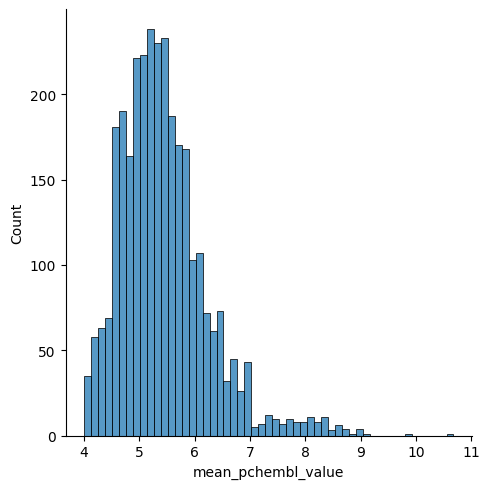

In [17]:
sns.displot(new_df.mean_pchembl_value)

### 2. Build a Quick Model 
This isn't meant to reflect best practices, I just want to build a quick model to make sure the data is ok. 

Instantiate a fingerprint generator from useful_rdkit_utils. 

In [18]:
smi2fp = uru.Smi2Fp()
new_df['fp'] = new_df.canonical_smiles.apply(smi2fp.get_np_counts)

Split the data into training and test sets. Again, this wasn't meant to be rigorous. 

In [19]:
train, test = train_test_split(new_df)

Create anad train a LightGBM regressor. 

In [20]:
lgbm = LGBMRegressor(verbose=-1)
lgbm.fit(np.stack(train.fp),train.mean_pchembl_value)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Predict on the test set and evaluate the predictions. 

/opt/homebrew/Caskroom/miniforge/base/envs/rdkit_2026_04/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'Predicted hERG pIC50')

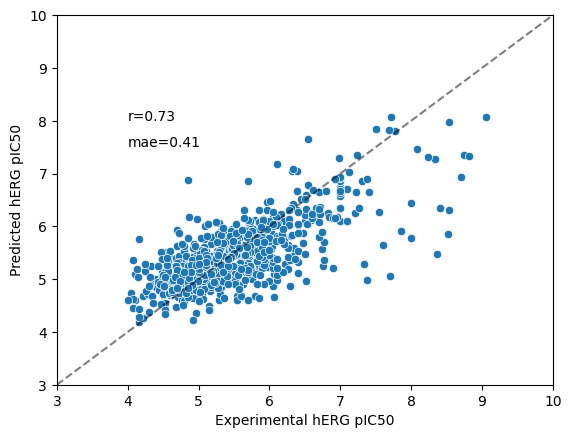

In [21]:
pred = lgbm.predict(np.stack(test.fp))
ax = sns.scatterplot(x=test.mean_pchembl_value,y=pred)
ax.axline((0, 0), slope=1, color='black', linestyle='--', alpha=0.5)
limit_min, limit_max = [3,10]
ax.set_xlim(limit_min, limit_max)
ax.set_ylim(limit_min, limit_max)
r =  pearsonr(test.mean_pchembl_value,pred).statistic
mae = mean_absolute_error(test.mean_pchembl_value,pred)
ax.text(4,8,f"r={r:.2f}")
ax.text(4,7.5,f"mae={mae:.2f}")
ax.set_xlabel("Experimental hERG pIC50")
ax.set_ylabel("Predicted hERG pIC50")